# KNN Regression Data (NO<sub>2</sub> Semarang)

K-Nearest Neighbors (KNN) Regression adalah salah satu metode dalam machine learning yang melakukan prediksi berdasarkan kedekatan data baru dengan beberapa data historis yang mirip. Pada proses prediksi, algoritma akan mencari K data terdekat (nearest neighbors) lalu menghitung rata-rata dari nilai target pada tetangga tersebut sebagai hasil prediksi.

Dalam konteks kasus prediksi NO₂, nilai lag (misalnya NO₂ dua hari sebelumnya hingga lima hari sebelumnya) digunakan sebagai fitur yang menggambarkan kondisi historis. KNN kemudian akan mencari periode di masa lalu yang memiliki pola lag yang mirip, lalu memprediksi kadar NO₂ besok dengan mengambil rata-rata kadar NO₂ yang terjadi pada periode-periode yang mirip tersebut.



# Mengapa R-Squared dan MSE Rendah pada Eksperimen?

R-Squared yang rendah menunjukkan bahwa variasi kadar NO₂ besok tidak cukup dapat dijelaskan hanya dengan data lag 2–5 hari sebelumnya. Hal ini masuk akal karena variabel lingkungan yang sangat memengaruhi kadar NO₂ tidak dimasukkan sebagai fitur dalam model. Dengan demikian, KNN hanya "menebak" dari pola serupa di masa lalu menggunakan informasi yang sangat terbatas.

# Modeling Data NO<sub>2</sub> Semarang

Dalam modeling ini dibuat sesuai dengan eksperiment data supervised yaitu dengan data yang menggunakan 2 hari sebelumnya hingga 5 hari

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

## Membaca Dokumen

In [2]:
day2 = pd.read_csv('../data/data-copernicus/day2.csv')
day3 = pd.read_csv('../data/data-copernicus/day3.csv')
day4 = pd.read_csv('../data/data-copernicus/day4.csv')
day5 = pd.read_csv('../data/data-copernicus/day5.csv')

## Modeling Data t1, t2

In [3]:
X = day2.drop(columns=['NO2'])
y = day2['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
day2_predict = knn.predict(X_test_scaled)
r2_day2 = r2_score(y_test, day2_predict)
mse_day2 = mean_squared_error(y_test, day2_predict)

print("MSE:", mse_day2)
print("R2:", r2_day2)

MSE: 1.1280072659822796e-10
R2: 0.43466130411390436


## Modeling Data t1, t2, t3

In [4]:
X = day3.drop(columns=['NO2'])
y = day3['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
day3_predict = knn.predict(X_test_scaled)
r2_day3 = r2_score(y_test, day3_predict)
mse_day3 = mean_squared_error(y_test, day3_predict)

print("MSE:", mse_day3)
print("R2:", r2_day3)

MSE: 7.695556391068492e-11
R2: 0.4348024063666973


## Modeling Data t1, t2, t3, t4

In [5]:
X = day4.drop(columns=['NO2'])
y = day4['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
day4_predict = knn.predict(X_test_scaled)
r2_day4 = r2_score(y_test, day4_predict)
mse_day4 = mean_squared_error(y_test, day4_predict)

print("MSE:", mse_day4)
print("R2:", r2_day4)

MSE: 1.6143569397611133e-10
R2: 0.0663970116222945


## Modeling Data t1, t2, t3, t4, t5

In [6]:
X = day5.drop(columns=['NO2'])
y = day5['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
day5_predict = knn.predict(X_test_scaled)
r2_day5 = r2_score(y_test, day5_predict)
mse_day5 = mean_squared_error(y_test, day5_predict)

print("MSE:", mse_day5)
print("R2:", r2_day5)

MSE: 1.1281165345522215e-10
R2: 0.33350553220304446


## Perbandingan R² Berdasarkan Banyak Hari yang digunakan

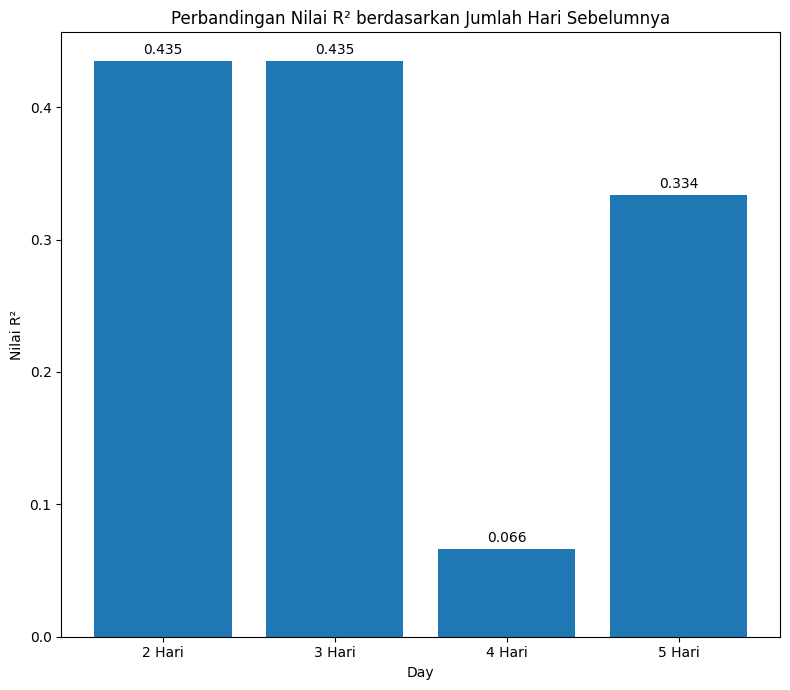

In [7]:
x = ['2 Hari', '3 Hari', '4 Hari', '5 Hari']
y = [r2_day2, r2_day3, r2_day4, r2_day5]

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.bar(x, y)

ax.set_title("Perbandingan Nilai R² berdasarkan Jumlah Hari Sebelumnya")
ax.set_xlabel("Day")
ax.set_ylabel("Nilai R²")   

ax.bar_label(bars, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()
